# 1) Packages Imports

In [1]:
import sys
import lib.dragon
sys.modules['dragon'] = sys.modules['lib.dragon']

In [2]:
import os
import sys
import importlib
import graphviz
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import torch
import torch.nn as nn
import openml

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

from dragon.search_space.bricks_variables import mlp_var, identity_var, operations_var, mlp_const_var, dag_var, node_var, activation_var
from dragon.search_space.base_variables import CatVar, Constant, DynamicBlock, IntVar, FloatVar, ArrayVar, Variable
from dragon.search_space.dag_encoding import AdjMatrix, Node
from dragon.search_space.dag_variables import NodeVariable, HpVar
from dragon.search_operators.base_neighborhoods import ArrayInterval, DynamicBlockInterval, CatInterval, ConstantInterval
from dragon.search_operators.dag_neighborhoods import CatHpInterval, NodeInterval
from dragon.utils.plot_functions import draw_cell, load_archi, str_operations

from dragon.utils.plot_functions import expr_to_mini_dag, graph_to_formula

import numpy as np
from dragon.utils.plot_functions import graph_to_formula


# 2) Data

## a) Unoised data

### Sentinel-2 Indices

In [101]:
df = pd.read_csv(f"data/6000_points.csv")
df = df.drop(columns=['system:index', 'QA60', '.geo'])
df = df.drop(columns=['date'])

#### SAVI (1/1)

In [513]:
df['SAVI'] = (df['B8']-df['B4'])/(df['B8']+df['B4']+0.5)*(1.5)

#### NDVI (1/1)

In [81]:
df['NDVI'] = (df['B8']-df['B4'])/(df['B8']+df['B4'])

#### BSI (0/1)

In [4]:
# Precedent incorrect not found formula: df['BSI'] = (df['B6'] + df['B4'] - df['B5'] - df['B2']) / (df['B6'] + df['B4'] + df['B5'] + df['B2'])
#BSI = ( (SWIR1 + RED) - (NIR + BLUE)) / SWIR1+RED) + (NIR +BLUE)) on Sentinel 2
#BSI = ((B11 + B04) - (B08 + B02)) / ((B11 + B04) + (B08 + B02)) on Sentinel 2

# NIR = B8
# RED = B4
# SWIR1 = B11
# BLUE = B2

# Normalized (  Best loss = 0.75657829 at max complexity 6)
# df['B11'] = np.random.normal(0, 100, size=len(df))
# df['B8'] = np.random.normal(0, 100, size=len(df))
# df['B4'] = np.random.normal(0, 100, size=len(df))
# df['B2'] = np.random.normal(0, 100, size=len(df))


df['BSI'] = (df['B11'] + df['B4'] - df['B8'] - df['B2']) / (df['B11'] + df['B4'] + df['B8'] + df['B2'])



#### EVI2 (0/1)

In [33]:
df['EVI'] = 2.5 * (df['B8'] - df['B4']) / (df['B8'] + 2.4*df['B4'] + 1)

#### NDRE (B5) (1/1)

In [161]:
df['NDRE_B5'] = (df['B8A'] - df['B5']) / (df['B8A'] + df['B5'])

#### NDRE (B6) (1/1)

In [187]:
df['NDRE_B6'] = (df['B8A'] - df['B6']) / (df['B8A'] + df['B6'])

#### NDRE (B7) (1/1)

In [209]:
df['NDRE_B7'] = (df['B8A'] - df['B7']) / (df['B8A'] + df['B7'])

#### NIRv (0/1)

In [338]:
df['NIRv'] = df['B8'] * ((df['B8'] - df['B4']) / (df['B8'] + df['B4']))

#### OSAVI (1/1)

In [254]:
df['OSAVI'] = 1.16 * (df['B8'] - df['B4']) / (df['B8'] + df['B4'] + 0.16)

#### VARI (0/1)

In [278]:
df['VARI'] = (df['B3'] - df['B4']) / (df['B3'] + df['B4'] - df['B2'])

#### NDMI (0/1)

In [299]:
df['NDMI'] = (df['B8'] - df['B11']) / (df['B8'] + df['B11'])

#### MSI (1/1)

In [482]:
df['MSI'] = df['B11'] / df['B8']

#### NDWI (McFeeters) (1/1)

In [388]:
df['NDWI_McFeeters'] = (df['B3'] - df['B8']) / (df['B3'] + df['B8'])

#### NDWI (Gao style) (0/1)

In [409]:
df['NDWI_Gao'] = (df['B8'] - df['B11']) / (df['B8'] + df['B11'])

#### NBR (0/2)

In [430]:
df['NBR'] = (df['B8'] - df['B12']) / (df['B8'] + df['B12'])

#### NBR2 (0/1)

In [454]:
df['NBR2'] = (df['B11'] - df['B12']) / (df['B11'] + df['B12'])

#### BAI (0/1)

In [340]:
df['BAI'] = 1 / ((0.1 - df['B4'])**2 + (0.06 - df['B8'])**2)

#### MNDWI (1/1)

In [8]:
df['MNDWI'] = (df['B3'] - df['B11']) / (df['B3'] + df['B11'])

#### AWEI_sh (0/1)

In [29]:
df['AWEI_sh'] = df['B2'] + 2.5*df['B3'] - 1.5*(df['B11'] + df['B12']) - 0.25*df['B8']

#### AWEI_nsh

In [527]:
df['AWEI_nsh'] = 4*(df['B3'] - df['B11']) - (0.25*df['B8'] + 2.75*df['B12'])

#### WI2015

In [ ]:
df['WI2015'] = 1.7204 + 171*(df['B2'] + df['B3'] + df['B4']) - 3*(df['B2']*df['B3']) - 1.8*(df['B2']*df['B4']) - 48*(df['B3']*df['B4']) - 0.8*(df['B8']*df['B11'])

#### Green/Blue ratio

In [50]:
df['GREEN_BLUE_RATIO'] = df['B3'] / df['B2']

#### NDSI (1/1)

In [458]:
df['NDSI'] = (df['B3'] - df['B11']) / (df['B3'] + df['B11'])

#### Snow brightness (1/1)

In [435]:
df['SNOW_BRIGHTNESS'] = (df['B3'] + df['B2']) / 2

#### NDBI

In [ ]:
df['NDBI'] = (df['B11'] - df['B8']) / (df['B11'] + df['B8'])

#### IBI

In [ ]:
(NDBI - NDVI) / (NDBI + NDVI)

#### dNBR

In [ ]:
NBR_pre - NBR_post

In [76]:
df.head()

,B1,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,lat,lon,BSI
0,1380,-13.129750,2266,-40.563502,1101,-64.077537,1413,1716,1944,33.240718,2250,37.335014,-95.326731,0.826741
1,1317,90.469213,42,6.560378,503,-150.066351,247,208,190,152.995950,146,-21.011541,-124.765524,-2.192429
2,1162,-10.166344,1475,3.836341,850,55.032316,1036,1136,1265,-33.213816,1298,11.062935,-11.792313,4.793457
3,1286,-8.987023,444,150.839209,823,-124.279086,832,1995,2736,-135.957941,3134,-1.910390,114.546423,1.251405
4,1381,128.236410,1363,-39.102246,1016,-1.938873,1155,1617,1845,-8.150427,2015,27.868199,120.743335,2.195591


### Physics formulas

#### Hubble's law: $v = H_0 \, D$

In [36]:
import numpy as np
import pandas as pd

H0 = 70 # in km/s/Mpc

D = (np.random.rand(100) + 0.1) * 1000 # Distances between 0.1 and 1000 Mpc
B1 = (np.random.rand(100) + 0.1) * 100
B2 = (np.random.rand(100) + 0.1) * 10
B3 = (np.random.rand(100) + 0.1) * 1000

v = H0 * D

df = pd.DataFrame({"D": D, "HUBBLE": v, "B1": B1, "B2": B2, "B3": B3})
df.head()


,D,HUBBLE,B1,B2,B3
0,442.627623,30983.933638,97.166586,2.011573,923.471114
1,1043.848004,73069.360287,64.462185,2.059283,131.981350
2,306.531466,21457.202593,57.619195,8.304990,501.710746
3,854.781471,59834.702985,40.801263,8.002046,919.636411
4,676.035348,47322.474385,67.636791,4.648808,811.739181


#### Kepler's third law: $P^2 = \frac{4\pi^2}{k^2(M_{Sun} + M_{Earth})}a^3$

In [102]:
M_sun = (np.random.rand(100) + 0.1) * 1.989e30 # solar mass [kg]
M_planet = (np.random.rand(100) + 0.1) * 5.972e24 # Earth mass [kg]
a = (np.random.rand(100) + 0.1) * 1.496e11 # semi-major axis ~ 1 AU [m]
G_kep = 6.67430e-11

P = 2 * np.pi * np.sqrt(a**3 / (G_kep * (M_sun + M_planet))) # orbital period [s]

df = pd.DataFrame({"M_sun": M_sun, "M_planet": M_planet, "a": a})
df['KEPLER'] = P
df.head()

,M_sun,M_planet,a,KEPLER
0,1.055573e+30,1.771300e+24,1.070993e+11,2.623691e+07
1,1.140385e+30,5.737234e+24,1.330944e+11,3.496954e+07
2,1.679157e+30,1.472879e+24,1.364334e+11,2.990971e+07
3,1.720621e+30,6.023423e+24,4.397121e+10,5.406127e+06
4,5.142678e+29,2.290069e+24,5.036086e+10,1.212051e+07


#### Ideal gas law: $P = \frac{nRT}{V}$

In [616]:
n = (np.random.rand(100) + 0.1) * 10 # amount of substance [mol] (0.1 to ~11 mol)
T = (np.random.rand(100) + 0.1) * 500 # temperature [K] (50 to ~550 K)
V = (np.random.rand(100) + 0.1) * 0.1 # volume [m^3] (0.01 to ~0.11 m^3)
R = 8.314 # ideal gas constant [J/(mol·K)]

P_gas = n * R * T / V # pressure [Pa]

df = pd.DataFrame({"n": n, "T": T, "V": V})
df['IDEAL_GAS'] = P_gas
df.head()

,n,T,V,IDEAL_GAS
0,2.002545,301.874630,0.089930,55887.497067
1,4.805267,155.543068,0.096703,64259.970850
2,6.145474,458.047307,0.091983,254431.171951
3,10.631127,437.637505,0.054806,705789.355405
4,6.043148,124.101162,0.040873,152550.981962


#### Rydberg formula: $\frac{1}{λ} = R_H (\frac{1}{n_1^2} - \frac{1}{n_2^2})$

In [641]:
n1 = np.random.randint(1, 5, size=100).astype(float)
n2_offset = np.random.randint(1, 6, size=100)
n2 = (n1 + n2_offset).astype(float)

R_H = 1.097373e7

inv_lambda = R_H * (1/n1**2 - 1/n2**2) # inverse wavelength [m^-1]

df = pd.DataFrame({"n1": n1, "n2": n2})
df['RYDBERG'] = inv_lambda
df.head()

,n1,n2,RYDBERG
0,3.0,5.0,7.803541e+05
1,4.0,5.0,2.469089e+05
2,2.0,6.0,2.438607e+06
3,3.0,5.0,7.803541e+05
4,3.0,4.0,5.334452e+05


#### Newton gravitational law in absolute value $F = \frac{G \, m_1 \, m_2}{r^2}$

In [562]:
M = (np.random.rand(100) + 0.1) * 1.98*1e30 # Sun mass in kg
m = 100 * (np.random.rand(100) + 0.1) # 5.97*1e24 Earth mass in kg
r = (np.random.rand(100) + 0.1) * 6371 * 1e3 # Earth radius in meters
G = 6.67430e-11

F = G * M * m / r**2

df = pd.DataFrame({"M": M, "m": m, "r": r})
df['NEWTON'] = F
df.head()

,M,m,r,NEWTON
0,1.612223e+30,89.591801,1.862276e+06,2.779784e+09
1,1.614314e+30,15.588763,6.523163e+06,3.947197e+07
2,8.079483e+29,47.430730,5.793517e+06,7.620168e+07
3,8.003616e+29,74.224730,2.623126e+06,5.762386e+08
4,8.328712e+29,99.825343,6.627052e+06,1.263524e+08


## b) Noised data (based on EmpiricalBench from Miles Cramer code): 
https://github.com/MilesCranmer/pysr_paper/blob/9f4dcde6bf126a7ec1b51c0d6f5df9fe68b7a7a9/src/data/empirical_bench/equations.yml

### Hubble's law: $v = H_0 \, D$

In [52]:
H0_hubble = 73.3
D_hubble = np.linspace(1, 20, 100)
noise_hubble = np.random.normal(0, 100, size=len(D_hubble))

v_hubble = H0_hubble * D_hubble + noise_hubble

df = pd.DataFrame({"D": D_hubble})
df['HUBBLE'] = v_hubble
df.head()

,D,HUBBLE
0,1.000000,37.399406
1,1.191919,182.146190
2,1.383838,61.088844
3,1.575758,88.871606
4,1.767677,271.511169


### Kepler's third law: $P^2 = \frac{4\pi^2}{k^2(M_{Sun} + M_{Earth})}a^3$

In [29]:
k_kepler = 365.25**2 / 1.0**3 # days^2 / AU^3

a_kepler = np.linspace(0.38, 9.5, 100) # semi-major axis [AU]
noise_kepler = np.random.normal(0, 0.002, size=len(a_kepler)) # relative noise, scale=0.002
P_kepler = np.sqrt(k_kepler * a_kepler**3) * (1 + noise_kepler) # period [days]

df = pd.DataFrame({"a": a_kepler})
df['KEPLER'] = P_kepler
df.head()

,a,KEPLER
0,0.380000,85.430258
1,0.472121,118.556128
2,0.564242,155.233381
3,0.656364,194.199413
4,0.748485,237.143010


### Newton gravitational law in absolute value $F = \frac{G \, m_1 \, m_2}{r^2}$

In [86]:
G_newton = 6.67408e-11 # gravitational constant [m^3 kg^-1 s^-2]

r_newton = np.exp(np.random.uniform(np.log(3.7e8), np.log(7.37593e12), size=100)) # distance [m]
m1_newton = np.exp(np.random.uniform(np.log(1.3e22), np.log(2e30), size=100)) # mass 1 [kg]
m2_newton = np.exp(np.random.uniform(np.log(1.3e22), np.log(2e30), size=100)) # mass 2 [kg]

F_newton = G_newton * m1_newton * m2_newton / r_newton**2 # force [N]
noise_newton = np.random.normal(0, 0.10, size=len(F_newton)) # 10% relative noise
F_newton = F_newton * (1 + noise_newton)

df = pd.DataFrame({"r": r_newton, "m1": m1_newton, "m2": m2_newton})
df['NEWTON'] = F_newton
df.head()

,r,m1,m2,NEWTON
0,4.125388e+09,4.432386e+22,1.965208e+26,4.115844e+19
1,3.853673e+10,2.402545e+24,3.706334e+22,4.191920e+15
2,6.155617e+08,8.728779e+25,2.137726e+29,2.907300e+27
3,2.238836e+11,8.526038e+29,7.256583e+23,7.979531e+20
4,7.507358e+08,1.063409e+26,1.865807e+22,2.210604e+20


### Ideal gas law: $P = \frac{nRT}{V}$

In [89]:
R_gas = 8.314 # J/(mol·K)

n_gas = np.random.uniform(1, 100, size=100) # number density [mol]
T_gas = np.random.uniform(300, 400, size=100) # temperature [K]
V_gas = np.random.uniform(1, 100, size=100) # volume [m^3]

P_ideal = n_gas * R_gas * T_gas / V_gas # pressure [Pa]
noise_gas = np.random.normal(0, 0.10, size=100) # 10% relative noise
P_ideal = P_ideal * (1 + noise_gas)

df = pd.DataFrame({"n": n_gas, "T": T_gas, "V": V_gas})
df['IDEAL_GAS'] = P_ideal
df.head()

,n,T,V,IDEAL_GAS
0,92.896911,335.269327,17.153446,15560.636427
1,88.903183,321.017377,12.804229,18872.440512
2,99.538385,306.687495,61.553052,3746.866186
3,39.051683,350.595431,2.890587,45231.281699
4,85.512733,355.720902,79.242461,3218.554962


### Rydberg formula: $\frac{1}{λ} = R_H (\frac{1}{n_1^2} - \frac{1}{n_2^2})$

In [26]:
R_H_ryd = 1.097e7  # Rydberg constant [m^-1]

rng = np.random.default_rng()
n1_ryd = rng.integers(1, 7, size=200).astype(float) # n1 in {1,2,3,4,5,6}
n2_ryd = np.array([rng.integers(int(n1_ryd[i]) + 1, 8) for i in range(200)]).astype(float) # n2 > n1, up to 7

lam_ryd = 1.0 / (R_H_ryd * (1.0 / n1_ryd**2 - 1.0 / n2_ryd**2)) # wavelength [m]
noise_ryd = np.random.normal(0, 0.01, size=200) # 1% relative noise
lam_ryd = lam_ryd * (1 + noise_ryd)

df = pd.DataFrame({"n1": n1_ryd, "n2": n2_ryd})
df['RYDBERG'] = lam_ryd
df.head()

,n1,n2,RYDBERG
0,4.0,6.0,2.603375e-06
1,3.0,7.0,1.017977e-06
2,3.0,4.0,1.903497e-06
3,1.0,3.0,1.024629e-07
4,3.0,7.0,9.890061e-07


## X and z definition

In [82]:
output = 'NDVI' # NDVI, SAVI, BSI, TEST, NEWTON, HUBBLE, IDEAL_GAS, RYDBERG, KEPLER, EVI, NDRE_B5, NIRv, OSAVI, VARI, NDMI, MSI, NDWI_McFeeters, NDWI_Gao, NBR, BAI, MNDWI, AWEI_sh
X = df.drop([output], axis=1)
z = df[[output]]

In [83]:
X.head()

,B1,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,lat,lon
0,1380,3202,2266,1245,1101,1240,1413,1716,1944,1959,2250,37.335014,-95.326731
1,1317,49,42,889,503,288,247,208,190,141,146,-21.011541,-124.765524
2,1162,2031,1475,951,850,968,1036,1136,1265,1185,1298,11.062935,-11.792313
3,1286,1291,444,980,823,532,832,1995,2736,2485,3134,-1.910390,114.546423
4,1381,2050,1363,1126,1016,975,1155,1617,1845,1806,2015,27.868199,120.743335


In [84]:
z.head()

,NDVI
0,0.224758
1,-0.342657
2,0.100790
3,0.647332
4,0.298813


## c) Denoising

In [85]:
# Denoise

## Variable augmentation

In [86]:
# ═══════════════════════════════════════════════════════════════════════
# Variable Augmentation — greedy forward selection with shallow RF
# ═══════════════════════════════════════════════════════════════════════
from itertools import combinations
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

F32_MAX = np.finfo(np.float32).max  # ~3.4e38 — sklearn's internal limit

cols = X.columns.tolist()
y_aug = z.values.ravel()
n = len(y_aug)

candidates = {}

# Unary: x², 1/x, √|x|, -x
for c in cols:
    v = X[c].values.astype(np.float64)
    candidates[f"({c})**2"] = v ** 2
    with np.errstate(divide='ignore', invalid='ignore'):
        candidates[f"1/({c})"] = np.where(np.abs(v) > 1e-12, 1.0 / v, 0.0)
    candidates[f"sqrt(|{c}|)"] = np.sqrt(np.abs(v))
    candidates[f"-({c})"] = -v

# Binary: xi+xj, xi-xj, xi*xj, xi/xj
for ci, cj in combinations(cols, 2):
    vi, vj = X[ci].values.astype(np.float64), X[cj].values.astype(np.float64)
    candidates[f"({ci}+{cj})"] = vi + vj
    candidates[f"({ci}-{cj})"] = vi - vj
    candidates[f"({cj}-{ci})"] = vj - vi
    candidates[f"({ci}*{cj})"] = vi * vj
    with np.errstate(divide='ignore', invalid='ignore'):
        candidates[f"({ci}/{cj})"] = np.where(np.abs(vj) > 1e-12, vi / vj, 0.0)
        candidates[f"({cj}/{ci})"] = np.where(np.abs(vi) > 1e-12, vj / vi, 0.0)

# Clean: replace inf/nan → 0, clamp to float32 range, drop constants
clean = {}
for name, vals in candidates.items():
    vals = np.where(np.isfinite(vals), vals, 0.0)
    vals = np.clip(vals, -F32_MAX, F32_MAX)
    if np.std(vals) < 1e-15:
        continue
    clean[name] = vals
candidates = clean

print(f"Generated {len(candidates)} valid candidates")

# ── Fixed train/test split indices ───────────────────────────────────
idx_tr, idx_te = train_test_split(np.arange(n), test_size=0.25, random_state=42)
X_base = X.values.astype(np.float64)
X_base = np.clip(X_base, -F32_MAX, F32_MAX)
Xtr, Xte = X_base[idx_tr], X_base[idx_te]
ytr, yte = y_aug[idx_tr], y_aug[idx_te]

def rf_r2(X_tr, X_te):
    rf = RandomForestRegressor(n_estimators=30, max_depth=4, random_state=42, n_jobs=-1)
    rf.fit(X_tr, ytr)
    return rf.score(X_te, yte)

r2_base = rf_r2(Xtr, Xte)
print(f"Baseline R² (shallow RF, depth=4): {r2_base:.6f}\n")

# ── Step 1: pick best single augmentation ────────────────────────────
print("Step 1: scoring candidates individually...")
scores1 = {}
for name, vals in candidates.items():
    Xtr1 = np.column_stack([Xtr, vals[idx_tr]])
    Xte1 = np.column_stack([Xte, vals[idx_te]])
    scores1[name] = rf_r2(Xtr1, Xte1)

ranked1 = sorted(scores1.items(), key=lambda kv: kv[1], reverse=True)
aug1_name = ranked1[0][0]

print(f"Top-10 (step 1):")
for nm, sc in ranked1[:10]:
    print(f"  {nm:40s}  R² = {sc:.6f}  (Δ = {sc - r2_base:+.6f})")

# ── Step 2: fix aug1, pick best complementary augmentation ───────────
print(f"\nStep 2: scoring with aug1 = {aug1_name} fixed...")
aug1_vals = candidates[aug1_name]
Xtr_w1 = np.column_stack([Xtr, aug1_vals[idx_tr]])
Xte_w1 = np.column_stack([Xte, aug1_vals[idx_te]])
r2_w1 = rf_r2(Xtr_w1, Xte_w1)

scores2 = {}
for name, vals in candidates.items():
    if name == aug1_name:
        continue
    corr = np.abs(np.corrcoef(aug1_vals, vals)[0, 1])
    if corr > 0.95:
        continue
    Xtr2 = np.column_stack([Xtr_w1, vals[idx_tr]])
    Xte2 = np.column_stack([Xte_w1, vals[idx_te]])
    scores2[name] = rf_r2(Xtr2, Xte2)

ranked2 = sorted(scores2.items(), key=lambda kv: kv[1], reverse=True)
aug2_name = ranked2[0][0]

print(f"Top-10 (step 2):")
for nm, sc in ranked2[:10]:
    print(f"  {nm:40s}  R² = {sc:.6f}  (Δ = {sc - r2_w1:+.6f})")

# ── Add to X ─────────────────────────────────────────────────────────
print(f"\n>>> Aug 1: {aug1_name}  (R² = {ranked1[0][1]:.6f})")
print(f">>> Aug 2: {aug2_name}  (R² = {ranked2[0][1]:.6f})")

X[aug1_name] = candidates[aug1_name]
X[aug2_name] = candidates[aug2_name]
print(f"\nX: {X.shape[1]} features. New columns: {aug1_name}, {aug2_name}")
X.head()

Generated 520 valid candidates
Baseline R² (shallow RF, depth=4): 0.944816

Step 1: scoring candidates individually...
Top-10 (step 1):
  (B8/B4)                                   R² = 0.997095  (Δ = +0.052280)
  (B4/B8)                                   R² = 0.997094  (Δ = +0.052278)
  (B4-B8)                                   R² = 0.978451  (Δ = +0.033635)
  (B8-B4)                                   R² = 0.978427  (Δ = +0.033612)
  (B4/B8A)                                  R² = 0.977546  (Δ = +0.032730)
  (B8A/B4)                                  R² = 0.977546  (Δ = +0.032730)
  (B4/B7)                                   R² = 0.975726  (Δ = +0.030910)
  (B7/B4)                                   R² = 0.975720  (Δ = +0.030904)
  (B3/B8)                                   R² = 0.975659  (Δ = +0.030843)
  (B8/B3)                                   R² = 0.975615  (Δ = +0.030799)

Step 2: scoring with aug1 = (B8/B4) fixed...
Top-10 (step 2):
  (B1)**2                                   R² = 0.

,B1,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,lat,lon,(B8/B4),(B1)**2
0,1380,3202,2266,1245,1101,1240,1413,1716,1944,1959,2250,37.335014,-95.326731,1.579839,1904400.0
1,1317,49,42,889,503,288,247,208,190,141,146,-21.011541,-124.765524,0.489583,1734489.0
2,1162,2031,1475,951,850,968,1036,1136,1265,1185,1298,11.062935,-11.792313,1.224174,1350244.0
3,1286,1291,444,980,823,532,832,1995,2736,2485,3134,-1.910390,114.546423,4.671053,1653796.0
4,1381,2050,1363,1126,1016,975,1155,1617,1845,1806,2015,27.868199,120.743335,1.852308,1907161.0


# 3) Feature Importance with XGBoost

Feature Importance Ranking:
    feature  importance
13  (B8/B4)    0.999253
8        B7    0.000168
12      lon    0.000138
0        B1    0.000108
9        B8    0.000079
5        B4    0.000047
11      lat    0.000036
1       B11    0.000032
7        B6    0.000030
10      B8A    0.000029
2       B12    0.000024
6        B5    0.000022
4        B3    0.000019
3        B2    0.000014
14  (B1)**2    0.000000

Feature Scores Dictionary:
{'(B8/B4)': 0.9992534518241882, 'B7': 0.00016842561308294535, 'lon': 0.0001375189021928236, 'B1': 0.00010779145668493584, 'B8': 7.944091339595616e-05, 'B4': 4.6703666157554835e-05, 'lat': 3.5714201658265665e-05, 'B11': 3.249557630624622e-05, 'B6': 2.9999773687450215e-05, 'B8A': 2.94833898806246e-05, 'B12': 2.3902506654849276e-05, 'B5': 2.232127371826209e-05, 'B3': 1.8726836060523055e-05, 'B2': 1.4042152542970143e-05, '(B1)**2': 0.0}


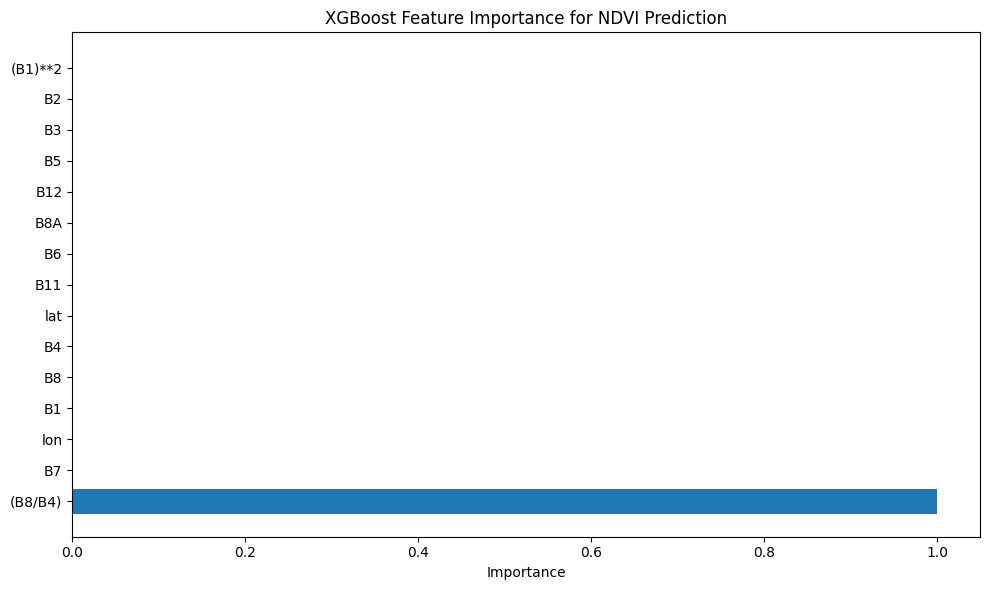


Top 10 features:
['(B8/B4)', 'B7', 'lon', 'B1', 'B8', 'B4', 'lat', 'B11', 'B6', 'B8A']

Shape of original features: (2620, 15)
Shape of selected features: (2620, 10)


In [87]:
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Normalize features for XGBoost
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# Also normalize the target — critical for large-scale data (e.g. Newton's law)
scaler_z = StandardScaler()
z_scaled = scaler_z.fit_transform(z).ravel()

# Train XGBoost model for feature importance
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_scaled, z_scaled)

# Get feature importances
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance Ranking:")
print(feature_importance)

# Create dictionary with performance scores for each feature
feature_scores_dict = dict(zip(feature_importance['feature'], feature_importance['importance']))
print("\nFeature Scores Dictionary:")
print(feature_scores_dict)

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance for NDVI Prediction')
plt.tight_layout()
plt.show()

# Select top features (e.g., top 10)
top_n = 10
top_features = feature_importance.head(top_n)['feature'].tolist()
print(f"\nTop {top_n} features:")
print(top_features)

# Use selected features for your symbolic regression
X_selected = X[top_features]
print(f"\nShape of original features: {X.shape}")
print(f"Shape of selected features: {X_selected.shape}")

In [88]:
num_keep_features = X.shape[1]
top_features = feature_importance.head(num_keep_features)['feature'].tolist()
X.drop(columns=[col for col in X.columns if col not in top_features], inplace=True)

In [89]:
X.head()

,B1,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,lat,lon,(B8/B4),(B1)**2
0,1380,3202,2266,1245,1101,1240,1413,1716,1944,1959,2250,37.335014,-95.326731,1.579839,1904400.0
1,1317,49,42,889,503,288,247,208,190,141,146,-21.011541,-124.765524,0.489583,1734489.0
2,1162,2031,1475,951,850,968,1036,1136,1265,1185,1298,11.062935,-11.792313,1.224174,1350244.0
3,1286,1291,444,980,823,532,832,1995,2736,2485,3134,-1.910390,114.546423,4.671053,1653796.0
4,1381,2050,1363,1126,1016,975,1155,1617,1845,1806,2015,27.868199,120.743335,1.852308,1907161.0


In [90]:
X.shape

(2620, 15)

In [91]:
z.head()

,NDVI
0,0.224758
1,-0.342657
2,0.100790
3,0.647332
4,0.298813


# 4) Meta Architecture

In [92]:
class MetaArchi(nn.Module):
    def __init__(self, args, input_shape):
        super().__init__()
        self.input_shape = input_shape
        assert isinstance(args['Dag'], AdjMatrix), f"The 'Dag' argument should be an 'AdjMatrix'. Got {type(args['Dag'])} instead."
        self.dag = args['Dag']
        self.dag.set(input_shape)


    def forward(self, X):
        return self.dag(X)
    def set_prediction_to_save(self, name, df):
        if hasattr(self, "prediction"):
            self.prediction[name] = df
        else:
            self.prediction = {name: df}
    def save(self, path):
        if not os.path.exists(path):
            os.makedirs(path)
        full_path = os.path.join(path, "best_model.pth")
        torch.save(self.state_dict(), full_path)
        if hasattr(self, "prediction"):
            for k in self.prediction.keys():
                self.prediction[k].to_csv(os.path.join(path, f"best_model_{k}_outputs.csv"))

In [93]:
class RegressionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.DoubleTensor(X.values)   # float64 — critical for large-scale data
        self.y = torch.DoubleTensor(y.values)    # float64

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_set = RegressionDataset(X, z)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)

#### All possible combinations of feature indices for Select Features

In [94]:
from itertools import combinations

# Generate all possible combinations of feature indices
all_feature_combinations = []
num_features = X.shape[1]

if num_features == 1:
    all_feature_combinations = [[0]]
else:
    for length in range(1, num_features):
        all_feature_combinations.extend([list(combo) for combo in combinations(range(num_features), length)])


In [95]:
all_feature_combinations

[[0],
 [1],
 [2],
 [3],
 [4],
 [5],
 [6],
 [7],
 [8],
 [9],
 [10],
 [11],
 [12],
 [13],
 [14],
 [0, 1],
 [0, 2],
 [0, 3],
 [0, 4],
 [0, 5],
 [0, 6],
 [0, 7],
 [0, 8],
 [0, 9],
 [0, 10],
 [0, 11],
 [0, 12],
 [0, 13],
 [0, 14],
 [1, 2],
 [1, 3],
 [1, 4],
 [1, 5],
 [1, 6],
 [1, 7],
 [1, 8],
 [1, 9],
 [1, 10],
 [1, 11],
 [1, 12],
 [1, 13],
 [1, 14],
 [2, 3],
 [2, 4],
 [2, 5],
 [2, 6],
 [2, 7],
 [2, 8],
 [2, 9],
 [2, 10],
 [2, 11],
 [2, 12],
 [2, 13],
 [2, 14],
 [3, 4],
 [3, 5],
 [3, 6],
 [3, 7],
 [3, 8],
 [3, 9],
 [3, 10],
 [3, 11],
 [3, 12],
 [3, 13],
 [3, 14],
 [4, 5],
 [4, 6],
 [4, 7],
 [4, 8],
 [4, 9],
 [4, 10],
 [4, 11],
 [4, 12],
 [4, 13],
 [4, 14],
 [5, 6],
 [5, 7],
 [5, 8],
 [5, 9],
 [5, 10],
 [5, 11],
 [5, 12],
 [5, 13],
 [5, 14],
 [6, 7],
 [6, 8],
 [6, 9],
 [6, 10],
 [6, 11],
 [6, 12],
 [6, 13],
 [6, 14],
 [7, 8],
 [7, 9],
 [7, 10],
 [7, 11],
 [7, 12],
 [7, 13],
 [7, 14],
 [8, 9],
 [8, 10],
 [8, 11],
 [8, 12],
 [8, 13],
 [8, 14],
 [9, 10],
 [9, 11],
 [9, 12],
 [9, 13],
 [9, 14],


### Search space definition

In [96]:
from dragon.search_operators.base_neighborhoods import CatInterval, ConstantInterval, FloatInterval
from dragon.search_operators.dag_neighborhoods import EvoDagInterval, HpInterval
from dragon.search_space.base_variables import CatVar, Constant
from dragon.search_space.bricks.basics import Identity
from dragon.search_space.bricks.symbolic_regression import *
from dragon.search_space.dag_variables import EvoDagVariable, HpVar
from dragon.search_space.bricks_variables import (
    operations_var,
    dag_var,
)
from dragon.search_space.base_variables import ArrayVar
from dragon.search_space.dag_encoding import SymbolicNode
from dragon.search_operators.base_neighborhoods import ArrayInterval

# ── Feature importance → CatVar weights ──────────────────────────────
# Build a per-feature probability vector aligned with X.columns,
# then convert it into per-combination weights for the CatVar.
feature_names_list = X.columns.tolist()
num_feat = len(feature_names_list)
feature_probs = [feature_scores_dict.get(col, 1.0 / num_feat)
                 for col in feature_names_list]

combo_weights = SelectFeatures.combination_weights(
    feature_probs, all_feature_combinations
) 
#combo_weights = [1.0 / len(all_feature_combinations)] * len(all_feature_combinations)

# ── Search-space variables ────────────────────────────────────────────
unary_var = HpVar(
    "UnaryOp",
    CatVar(
        "UnaryOpType",
        features=[Identity, Inverse, Negate],
        neighbor=CatInterval()
    ),
    hyperparameters={},
    neighbor=HpInterval()
)
select_features_var = HpVar(
    "SelectFeatures",
    Constant("SelectFeaturesOp", SelectFeatures, neighbor=ConstantInterval()),
    hyperparameters={
        "feature_indices": CatVar(
            "feature_indices",
            features=all_feature_combinations,
            weights=combo_weights,# biased by XGBoost importance
            neighbor=CatInterval()
        )
    },
    neighbor=HpInterval()
)

power_features_var = HpVar(
    "Power",
    Constant("PowerOp", Power, neighbor=ConstantInterval()),
    hyperparameters={
        "exponent": CatVar(
            "exponent",
            features=[-3, -2, -1, 1, 2, 3],
            neighbor=CatInterval()
        )
    },
    neighbor=HpInterval()
)


sum_var = HpVar(
    "Sum",
    Constant("SumOp", SumFeatures, neighbor=ConstantInterval()),
    hyperparameters={},
    neighbor=HpInterval()
)

const_var = HpVar(
    "Constant",
    Constant("ConstantOp", ConstantBrick, neighbor=ConstantInterval()),
    hyperparameters={},
    neighbor=HpInterval()
)

# sqrt_var = HpVar(
#     "Sqrt",
#     Constant("SqrtOp", Sqrt, neighbor=ConstantInterval()),
#     hyperparameters={},
#     neighbor=HpInterval()
# )


candidate_operations = operations_var(
    "CandidateOperations",
    size=6,
    candidates=[
        select_features_var,
        unary_var,
        power_features_var,
        # sqrt_var,
        # sum_var,
        # const_var
    ],
    combiner_features=['add', 'mul'],
    activations=Constant(
        "id",
        value=nn.Identity(),
        neighbor=ConstantInterval()
    ),
    node_type=SymbolicNode
)


dag = EvoDagVariable(
                    label="Dag",
                    operations = candidate_operations,
                    init_complexity=4,
                    neighbor=EvoDagInterval(nb_mutations=2)
                )


search_space = ArrayVar(dag, label="Search Space", neighbor=ArrayInterval())

# 5) LOSS

### LOSS 1: without constants optimization

#### Custom loss function: Correlation

In [97]:
def correl(pred, true):
    """Calculates the Pearson correlation coefficient"""
    # Convert to numpy if needed
    if isinstance(pred, torch.Tensor):
        pred = pred.numpy()
    if isinstance(true, torch.Tensor):
        true = true.numpy()
    
    # Calculate deviations from mean
    pred_dev = pred - pred.mean()
    true_dev = true - true.mean()
    
    # Calculate covariance
    cov = np.sum(pred_dev * true_dev)
    
    # Calculate standard deviations
    std_pred = np.sqrt(np.sum(pred_dev ** 2))
    std_true = np.sqrt(np.sum(true_dev ** 2))
    
    # Return correlation coefficient
    if std_pred == 0 or std_true == 0:
        return 0.0
    return cov / (std_pred * std_true + 1e-8)

#### Loss loop

In [98]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Get feature names and number of features dynamically
feature_names = X.columns.tolist()
num_features = X.shape[1]

def eval(args, eps=1e-1, num_features=num_features):
    model = MetaArchi(args, input_shape=(num_features,)).to(device)
    # params=sum(p.numel() for p in model.parameters())
    # print("parameters:", params)
    # if params==1:
    #     optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # increase the learning rate to speed up the converegence
    #     loss_fn = nn.MSELoss()
    #     max_initial_loss = 1e3  # skip optimization if first epoch loss exceeds this
    #     for epoch in range(100):
    #         model.train()
    #         epoch_loss = 0.0
    #         for Xb, yb in train_loader:
    #             Xb, yb = Xb.to(device), yb.to(device)
    #             optimizer.zero_grad()
    #             pred = model(Xb)
    #             loss = loss_fn(pred, yb)
    #             loss.backward()
    #             optimizer.step()
    #             epoch_loss += loss.item() * Xb.size(0)
    #         epoch_loss /= len(train_loader.dataset)
    #         if epoch == 0 and (epoch_loss > max_initial_loss or np.isnan(epoch_loss)):
    #             print(f"Initial loss too high ({epoch_loss:.2e}), skipping constant optimization")
    #             break
    #         if epoch_loss < eps:
    #             break
    #         print(f"Epoch {epoch+1}, Loss: {epoch_loss:.6f}")
            
    model.eval()

    all_pred, all_true = [], []

    with torch.no_grad():
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            pred = model(Xb)
            all_pred.append(pred.detach().cpu())
            all_true.append(yb.detach().cpu())
    pred_all = torch.cat(all_pred)
    true_all = torch.cat(all_true)

    mse = np.inf
    selected_c = 0

    if len(pred_all.shape) > 1:
        for c in range(pred_all.shape[-1]):
            loss = 1 -(correl(pred_all[:, c:c+1], true_all))**2
            if loss < mse:
                mse = loss
                selected_c = c
        pred_all = pred_all[:, selected_c]

    pred_all = pred_all.squeeze().numpy()
    true_all = true_all.squeeze().numpy()

    return model, pred_all, true_all, mse
    

from dragon.utils.plot_functions import graph_to_all_formulas
_best_loss_so_far = np.inf
_formula_log_path = "found_formulas.txt"

def loss_function(args, idx, eps=1e-1, mse_threshold=0.04, feature_names=feature_names, *kwargs):
    global _best_loss_so_far

    labels = [e.label for e in search_space]
    args = dict(zip(labels, args))

    model, y_pred, y_true, mse = eval(args, eps)

 # ── Log formula when a new best is found ──────────────────────────
    if mse < _best_loss_so_far:
        _best_loss_so_far = mse
        try:
            adj = model.dag.matrix
            nodes = model.dag.operations
            formulas = graph_to_all_formulas(adj, feature_names, nodes)
            with open(_formula_log_path, "a") as f:
                f.write(f"--- Idx={idx}  Loss={mse:.10f}  Selected channel={selected_c} ---\n")
                f.write(f"  Adj matrix:\n{adj}\n")
                f.write(f"  Nodes: {[str(n) for n in nodes]}\n")
                for i, formula in enumerate(formulas):
                    tag = " <<< SELECTED" if i == selected_c else ""
                    f.write(f"  Formula[{i}]: {formula}{tag}\n")
                f.write("\n")
            print(f"  >> NEW BEST logged to {_formula_log_path}: selected channel={selected_c}, formula={formulas[selected_c]}")
        except Exception as e:
            print(f"  >> Could not extract formula: {e}")

    print(
        f"Idx={idx}, MSE = {mse:.10f}"
    )
    
    df = pd.DataFrame({
        "pred": y_pred,
        "true": y_true
    })
    model.set_prediction_to_save("prediction", df)
    return mse.item(), model


#### Loss loop 2

In [105]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Get feature names and number of features dynamically
feature_names = X.columns.tolist()
num_features = X.shape[1]

# ── Fixed fingerprint batch (small subset for fast hashing) X.shape[0]//4 instead of 50 values──────────
_fingerprint_X = torch.tensor(X.values[:X.shape[0]//4], dtype=torch.float32).to(device)

def eval(args, eps=1e-1, num_features=num_features):
    model = MetaArchi(args, input_shape=(num_features,)).to(device)
    model.eval()

    all_pred, all_true = [], []

    with torch.no_grad():
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            pred = model(Xb)
            all_pred.append(pred.detach().cpu())
            all_true.append(yb.detach().cpu())
    pred_all = torch.cat(all_pred)
    true_all = torch.cat(all_true)

    mse = np.inf
    selected_c = 0

    if len(pred_all.shape) > 1:
        for c in range(pred_all.shape[-1]):
            loss = 1 -(correl(pred_all[:, c:c+1], true_all))**2
            if loss < mse:
                mse = loss
                selected_c = c
        pred_all = pred_all[:, selected_c]

    pred_all = pred_all.squeeze().numpy()
    true_all = true_all.squeeze().numpy()

    return model, pred_all, true_all, mse, selected_c
    

from dragon.utils.plot_functions import graph_to_all_formulas
_best_loss_so_far = np.inf
_formula_log_path = "found_formulas.txt"
_output_cache = {}  # fingerprint hash → (mse, y_pred, y_true, selected_c)

def _dag_fingerprint(model):
    """Hash the model's output on a fixed small batch — cheap & catches all duplicates."""
    with torch.no_grad():
        out = model(_fingerprint_X).cpu().numpy()
    # Round to 8 decimals to avoid floating-point noise
    return hash(np.round(out, 8).tobytes())

def loss_function(args, idx, eps=1e-1, mse_threshold=0.04, feature_names=feature_names, *kwargs):
    global _best_loss_so_far

    labels = [e.label for e in search_space]
    args = dict(zip(labels, args))

    # ── Check output cache before full evaluation ─────────────────────
    model = MetaArchi(args, input_shape=(num_features,)).to(device)
    model.eval()
    fp = _dag_fingerprint(model)

    if fp in _output_cache:
        mse, y_pred, y_true, selected_c = _output_cache[fp]
        print(f"Idx={idx}, SKIPPED (duplicate formula, loss was {mse:.10f})")
        df = pd.DataFrame({"pred": y_pred, "true": y_true})
        model.set_prediction_to_save("prediction", df)
        return 1, model  # penalize duplicate → search explores elsewhere, 1 instead of np.inf

    # ── Not cached: run full evaluation ───────────────────────────────
    model, y_pred, y_true, mse, selected_c = eval(args, eps)

    # Store in cache
    fp2 = _dag_fingerprint(model)  # re-fingerprint after eval (same model)
    _output_cache[fp2] = (mse, y_pred, y_true, selected_c)

    # ── Log formula when a new best is found ──────────────────────────
    if mse < _best_loss_so_far:
        _best_loss_so_far = mse
        try:
            adj = model.dag.matrix
            nodes = model.dag.operations
            formulas = graph_to_all_formulas(adj, feature_names, nodes)
            with open(_formula_log_path, "a") as f:
                f.write(f"--- Idx={idx}  Loss={mse:.10f}  Selected channel={selected_c} ---\n")
                f.write(f"  Adj matrix:\n{adj}\n")
                f.write(f"  Nodes: {[str(n) for n in nodes]}\n")
                for i, formula in enumerate(formulas):
                    tag = " <<< SELECTED" if i == selected_c else ""
                    f.write(f"  Formula[{i}]: {formula}{tag}\n")
                f.write("\n")
            print(f"  >> NEW BEST logged to {_formula_log_path}: selected channel={selected_c}, formula={formulas[selected_c]}")
        except Exception as e:
            print(f"  >> Could not extract formula: {e}")

    print(
        f"Idx={idx}, MSE = {mse:.10f}"
    )
    
    df = pd.DataFrame({
        "pred": y_pred,
        "true": y_true
    })
    model.set_prediction_to_save("prediction", df)
    return mse.item(), model

# 6a) Models initialisation

In [99]:
import random
from copy import deepcopy
from itertools import combinations as _comb

random.seed(42)
np.random.seed(42)
num_feat = X.shape[1]
feat_names = X.columns.tolist()
op_pool = []
for op_cls in [Identity, Inverse, Negate, SumFeatures]: # Sqrt removed
    op_pool.append((op_cls, {}))
for exp in [-3, -2, -1, 1, 2, 3]:
    op_pool.append((Power, {'exponent': exp}))
for idx in range(num_feat):
    op_pool.append((SelectFeatures, {'feature_indices': [idx]}))
for pair in _comb(range(num_feat), 2):
    op_pool.append((SelectFeatures, {'feature_indices': list(pair)}))
random.shuffle(op_pool)
def _chain(n):
    m = np.zeros((n, n), dtype=int)
    for i in range(n - 1): m[i, i+1] = 1
    return m
def _fan(n):
    m = np.zeros((n, n), dtype=int)
    if n <= 2: m[0,1] = 1; return m
    for i in range(1, n-1): m[0,i] = 1; m[i,n-1] = 1
    return m
def _skip(n):
    m = _chain(n)
    for i in range(n - 2): m[i, i+2] = 1
    return m
def _rand(n):
    m = _chain(n)
    for i in range(n):
        for j in range(i+2, n):
            if random.random() < 0.3: m[i,j] = 1
    return m
_topos = [_chain, _fan, _skip, _rand]
seed_dags = []
cursor = 0
for i in range(200):
    n = 3 + (i % 5)
    n_inner = n - 1
    mat = _topos[i % 4](n)
    ops = [op_pool[(cursor + j) % len(op_pool)] for j in range(n_inner)]
    cursor += n_inner
    pat = i % 4
    if pat == 0: combs = ['add'] * n_inner
    elif pat == 1: combs = ['mul'] * n_inner
    elif pat == 2: combs = ['add' if j%2==0 else 'mul' for j in range(n_inner)]
    else: combs = ['mul' if j%2==0 else 'add' for j in range(n_inner)]
    nodes = [Node(combiner='add', operation=Identity, hp={}, activation=nn.Identity())]
    for k in range(n_inner):
        cls, hp = ops[k]
        nodes.append(Node(combiner=combs[k], operation=cls, hp=deepcopy(hp), activation=nn.Identity()))
    try:
        seed_dags.append([AdjMatrix(matrix=mat, operations=nodes)])
    except:
        seed_dags.append([AdjMatrix(matrix=_chain(n), operations=nodes)])
from collections import Counter
op_c, feat_c, size_c = Counter(), Counter(), Counter()
for d in seed_dags:
    adj = d[0]
    size_c[len(adj.operations)] += 1
    for node in adj.operations[1:]:
        op_c[node.name.__name__] += 1
        if node.name == SelectFeatures and 'feature_indices' in node.hp:
            for fi in node.hp['feature_indices']:
                feat_c[feat_names[fi] if fi < len(feat_names) else fi] += 1
print(f"Generated {len(seed_dags)} seed DAGs")
print(f"Sizes: {dict(sorted(size_c.items()))}")
print(f"Ops: {dict(sorted(op_c.items()))}")
print(f"Features: {dict(sorted(feat_c.items()))}")
seed_models = seed_dags

Generated 200 seed DAGs
Sizes: {3: 40, 4: 40, 5: 40, 6: 40, 7: 40}
Ops: {'Identity': 6, 'Inverse': 6, 'Negate': 6, 'Power': 38, 'SelectFeatures': 738, 'SumFeatures': 6}
Features: {'(B1)**2': 94, '(B8/B4)': 90, 'B1': 93, 'B11': 92, 'B12': 91, 'B2': 94, 'B3': 92, 'B4': 93, 'B5': 95, 'B6': 91, 'B7': 92, 'B8': 91, 'B8A': 91, 'lat': 92, 'lon': 93}


# 6b) Search

In [100]:
from dragon.search_algorithm.mutant_ucb import Mutant_UCB
from dragon.search_space.bricks.symbolic_regression import Power, ConstantBrick
import shutil

for path in ["/save", "save"]:
    if os.path.isdir(path):
        shutil.rmtree(path)
        print(f"Deleted directory: {path}")

FINAL_THRESHOLD = 1e-7
MAX_COMPLEXITY  = 11        # max non-Identity nodes (6 → up to 7-node DAGs)
T_PER_LEVEL     = 300     # new evaluations per complexity level (1000 at first)
K_INIT          = 200
save_dir        = "save/NDVI_formula/"

# ─────────────────────────────────────────────────────────────────────────
#  Progressive-complexity exploration
# ─────────────────────────────────────────────────────────────────────────
global_best_loss = np.inf
found = False

for complexity in range(1, MAX_COMPLEXITY + 1):
    dag.complexity = complexity

    print(f"\n{'='*60}")
    print(f"  Complexity {complexity}  ({complexity+1} nodes incl. Identity)")
    print(f"{'='*60}")

    if complexity == 1:
        T_total   = T_PER_LEVEL * complexity
        clean_all = True
        extra_kw  = {}
    else:
        pop_size  = len(pd.read_csv(os.path.join(save_dir, "computation_file.csv")))
        T_total   = pop_size + T_PER_LEVEL * complexity
        clean_all = False
        extra_kw  = {"pop_path": save_dir}

    sa = Mutant_UCB(
        search_space   = search_space,
        evaluation     = loss_function,
        T              = T_total,
        K              = K_INIT,
        N              = 1,
        E              = 1000,
        save_dir       = save_dir,
        clean_all      = clean_all,
        verbose        = True,
        loss_threshold = FINAL_THRESHOLD,
        models=seed_models, # Initialisation with graphs defined in 6a)
        **extra_kw,
    )
    sa.run()

    level_best = sa.min_loss
    global_best_loss = min(global_best_loss, level_best)
    print(f"  -> complexity {complexity}: best={level_best:.8f} | global best={global_best_loss:.8f}")

    if global_best_loss <= FINAL_THRESHOLD:
        print(f"\n  Formula found at complexity {complexity}!")
        found = True
        break

# ── Exploitation pass ────────────────────────────────────────────────
dag.complexity = MAX_COMPLEXITY
pop_size  = len(pd.read_csv(os.path.join(save_dir, "computation_file.csv")))
T_exploit = pop_size + 2000

print(f"\n{'='*60}")
print(f"  Exploitation (E=0.01, 2000 new iters)")
print(f"{'='*60}")

sa = Mutant_UCB(
    search_space   = search_space,
    evaluation     = loss_function,
    T              = T_exploit,
    K              = K_INIT,
    N              = 1,
    E              = 0.01,
    save_dir       = save_dir,
    clean_all      = False,
    verbose        = True,
    pop_path       = save_dir,
    loss_threshold = FINAL_THRESHOLD,
)
sa.run()
global_best_loss = min(global_best_loss, sa.min_loss)

print(f"\n{'='*60}")
if global_best_loss <= FINAL_THRESHOLD:
    print(f"  Formula found! Final loss = {global_best_loss:.10f}")
else:
    print(f"  Best loss = {global_best_loss:.8f}")
print(f"{'='*60}")

Deleted directory: save

  Complexity 1  (2 nodes incl. Identity)
2026-04-08 08:49:52,976 | WARNING | Use multiple processes if you want to use the distributed version.
2026-04-08 08:49:53,005 | INFO | The whole population has been created (size = 200), 0 have been randomy initialized.
  >> NEW BEST logged to found_formulas.txt: selected channel=9, formula=B8**3
Idx=0, MSE = 0.7647788162
2026-04-08 08:49:53,036 | INFO | Best found! 0.7647788161988306 < inf
Idx=1, MSE = 0.9919129084
Idx=2, MSE = 1.0000000000
2026-04-08 08:49:53,066 | ERROR | Worker with individual 2 failed with 'float' object has no attribute 'item', set loss to inf
Traceback (most recent call last):
  File "/Users/elyaschikhaoui/Desktop/dragon/DRAGON/lib/dragon/search_algorithm/search_algorithm.py", line 324, in evaluate
    loss = timed_evaluation(x, idx, self.time_max*60, self.evaluation)
  File "/Users/elyaschikhaoui/Desktop/dragon/DRAGON/lib/dragon/search_algorithm/search_algorithm.py", line 513, in timed_evaluatio

## Other searches

In [ ]:
import subprocess, os, textwrap, tempfile

NUM_MPI_WORKERS = 8  # total processes (1 master + 3 workers)
FINAL_THRESHOLD = 1e-5
MAX_COMPLEXITY  = 15        # max non-Identity nodes (6 → up to 7-node DAGs)
T_PER_LEVEL     = 2000     # new evaluations per complexity level (1000 at first)
K_INIT          = 200

# ── Build the MPI script from current notebook state ─────────────────
# We serialise X, z and search_space to disk so the workers can reload them.
_tmp_dir = os.path.join("save", "_mpi_tmp")
os.makedirs(_tmp_dir, exist_ok=True)
X.to_csv(os.path.join(_tmp_dir, "X.csv"), index=False)
z.to_csv(os.path.join(_tmp_dir, "z.csv"), index=False)

import pickle
with open(os.path.join(_tmp_dir, "search_space.pkl"), "wb") as f:
    pickle.dump(search_space, f)
with open(os.path.join(_tmp_dir, "dag.pkl"), "wb") as f:
    pickle.dump(dag, f)

mpi_script = textwrap.dedent(f"""\
    \"\"\"Auto-generated MPI search script — launched from notebook.\"\"\"
    import sys, os
    sys.path.insert(0, os.path.abspath("."))
    import lib.dragon
    sys.modules['dragon'] = sys.modules['lib.dragon']

    import pickle, shutil
    import numpy as np
    import pandas as pd
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    from mpi4py import MPI

    from dragon.search_space.dag_encoding import AdjMatrix
    from dragon.search_algorithm.mutant_ucb import Mutant_UCB

    # ── MPI info ──────────────────────────────────────────────────────
    comm = MPI.COMM_WORLD
    rank = comm.Get_rank()

    # ── Reload data & search space ────────────────────────────────────
    _tmp_dir = {_tmp_dir!r}
    X = pd.read_csv(os.path.join(_tmp_dir, "X.csv"))
    z = pd.read_csv(os.path.join(_tmp_dir, "z.csv"))

    with open(os.path.join(_tmp_dir, "search_space.pkl"), "rb") as f:
        search_space = pickle.load(f)
    with open(os.path.join(_tmp_dir, "dag.pkl"), "rb") as f:
        dag = pickle.load(f)

    # ── Dataset & loader ──────────────────────────────────────────────
    class RegressionDataset(Dataset):
        def __init__(self, X, y):
            self.X = torch.DoubleTensor(X.values)
            self.y = torch.DoubleTensor(y.values)
        def __len__(self):
            return len(self.X)
        def __getitem__(self, idx):
            return self.X[idx], self.y[idx]

    train_set = RegressionDataset(X, z)
    train_loader = DataLoader(train_set, batch_size=32, shuffle=True)

    # ── Model ─────────────────────────────────────────────────────────
    class MetaArchi(nn.Module):
        def __init__(self, args, input_shape):
            super().__init__()
            self.input_shape = input_shape
            assert isinstance(args['Dag'], AdjMatrix)
            self.dag = args['Dag']
            self.dag.set(input_shape)
        def forward(self, X):
            return self.dag(X)
        def set_prediction_to_save(self, name, df):
            if hasattr(self, "prediction"):
                self.prediction[name] = df
            else:
                self.prediction = {{name: df}}
        def save(self, path):
            if not os.path.exists(path):
                os.makedirs(path)
            torch.save(self.state_dict(), os.path.join(path, "best_model.pth"))
            if hasattr(self, "prediction"):
                for k in self.prediction:
                    self.prediction[k].to_csv(os.path.join(path, f"best_model_{{k}}_outputs.csv"))

    # ── Loss ──────────────────────────────────────────────────────────
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    num_features = X.shape[1]

    def correl(pred, true):
        if isinstance(pred, torch.Tensor):
            pred = pred.numpy()
        if isinstance(true, torch.Tensor):
            true = true.numpy()
        pred_dev = pred - pred.mean()
        true_dev = true - true.mean()
        cov = np.sum(pred_dev * true_dev)
        std_pred = np.sqrt(np.sum(pred_dev ** 2))
        std_true = np.sqrt(np.sum(true_dev ** 2))
        if std_pred == 0 or std_true == 0:
            return 0.0
        return cov / (std_pred * std_true + 1e-8)

    def eval_model(args):
        model = MetaArchi(args, input_shape=(num_features,)).to(device)
        model.eval()
        all_pred, all_true = [], []
        with torch.no_grad():
            for Xb, yb in train_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                pred = model(Xb)
                all_pred.append(pred.detach().cpu())
                all_true.append(yb.detach().cpu())
        pred_all = torch.cat(all_pred)
        true_all = torch.cat(all_true)
        mse = np.inf
        selected_c = 0
        if len(pred_all.shape) > 1:
            for c in range(pred_all.shape[-1]):
                loss = 1 - correl(pred_all[:, c:c+1], true_all) ** 2
                if loss < mse:
                    mse = loss
                    selected_c = c
            pred_all = pred_all[:, selected_c]
        pred_all = pred_all.squeeze().numpy()
        true_all = true_all.squeeze().numpy()
        return model, pred_all, true_all, mse

    def loss_function(args, idx, *kwargs):
        labels = [e.label for e in search_space]
        args = dict(zip(labels, args))
        model, y_pred, y_true, mse = eval_model(args)
        print(f"Idx={{idx}}, MSE = {{mse:.10f}}", flush=True)
        df_pred = pd.DataFrame({{"pred": y_pred, "true": y_true}})
        model.set_prediction_to_save("prediction", df_pred)
        return mse.item(), model

    # ── Search params ─────────────────────────────────────────────────
    FINAL_THRESHOLD = {FINAL_THRESHOLD}
    MAX_COMPLEXITY  = {MAX_COMPLEXITY}
    T_PER_LEVEL     = {T_PER_LEVEL}
    K_INIT          = {K_INIT}
    SAVE_DIR        = {save_dir!r}

    # ── Clean save dir (rank 0 only) ─────────────────────────────────
    if rank == 0:
        for path in ["/save", "save"]:
            if os.path.isdir(path):
                shutil.rmtree(path)
        os.makedirs(_tmp_dir, exist_ok=True)
    comm.Barrier()

    global_best_loss = np.inf
    found = False

    for complexity in range(1, MAX_COMPLEXITY + 1):
        dag.complexity = complexity

        if rank == 0:
            print(f"\\n{{'='*60}}")
            print(f"  Complexity {{complexity}}  ({{complexity+1}} nodes incl. Identity)")
            print(f"{{'='*60}}", flush=True)

        if complexity == 1:
            T_total = T_PER_LEVEL
            clean_all = True
            extra_kw = {{}}
        else:
            if rank == 0:
                pop_size = len(pd.read_csv(os.path.join(SAVE_DIR, "computation_file.csv")))
            else:
                pop_size = None
            pop_size = comm.bcast(pop_size, root=0)
            T_total = pop_size + T_PER_LEVEL
            clean_all = False
            extra_kw = {{"pop_path": SAVE_DIR}}

        sa = Mutant_UCB(
            search_space   = search_space,
            evaluation     = loss_function,
            T              = T_total,
            K              = K_INIT,
            N              = 1,
            E              = 1000,
            save_dir       = SAVE_DIR,
            clean_all      = clean_all,
            verbose        = (rank == 0),
            loss_threshold = FINAL_THRESHOLD,
            **extra_kw,
        )
        sa.run()

        level_best = comm.bcast(sa.min_loss if rank == 0 else None, root=0)
        global_best_loss = min(global_best_loss, level_best)

        if rank == 0:
            print(f"  -> complexity {{complexity}}: best={{level_best:.8f}} | global best={{global_best_loss:.8f}}", flush=True)

        if global_best_loss <= FINAL_THRESHOLD:
            if rank == 0:
                print(f"\\n  Formula found at complexity {{complexity}}!")
            found = True
            break

    # ── Exploitation pass ─────────────────────────────────────────────
    if not found:
        dag.complexity = MAX_COMPLEXITY
        if rank == 0:
            pop_size = len(pd.read_csv(os.path.join(SAVE_DIR, "computation_file.csv")))
            print(f"\\n{{'='*60}}")
            print(f"  Exploitation (E=0.01, 2000 new iters)")
            print(f"{{'='*60}}", flush=True)
        else:
            pop_size = None
        pop_size = comm.bcast(pop_size, root=0)
        T_exploit = pop_size + 2000

        sa = Mutant_UCB(
            search_space   = search_space,
            evaluation     = loss_function,
            T              = T_exploit,
            K              = K_INIT,
            N              = 1,
            E              = 0.01,
            save_dir       = SAVE_DIR,
            clean_all      = False,
            verbose        = (rank == 0),
            pop_path       = SAVE_DIR,
            loss_threshold = FINAL_THRESHOLD,
        )
        sa.run()
        final_best = comm.bcast(sa.min_loss if rank == 0 else None, root=0)
        global_best_loss = min(global_best_loss, final_best)

    if rank == 0:
        print(f"\\n{{'='*60}}")
        if global_best_loss <= FINAL_THRESHOLD:
            print(f"  Formula found! Final loss = {{global_best_loss:.10f}}")
        else:
            print(f"  Best loss = {{global_best_loss:.8f}}")
        print(f"{{'='*60}}")
""")

script_path = os.path.join(os.getcwd(), "_mpi_search.py")
with open(script_path, "w") as f:
    f.write(mpi_script)

print(f"MPI script written to: {script_path}")
print(f"Launching with {NUM_MPI_WORKERS} MPI processes...\n", flush=True)

# ── Stream output live (line-by-line) instead of buffering ────────────
proc = subprocess.Popen(
    ["mpiexec", "-n", str(NUM_MPI_WORKERS), "python", "-u", script_path],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,   # merge stderr into stdout
    text=True,
    bufsize=1,                  # line-buffered
    cwd=os.path.dirname(script_path),
)

for line in proc.stdout:
    print(line, end="", flush=True)

proc.wait()
if proc.returncode != 0:
    print(f"\nMPI process exited with code {proc.returncode}")
else:
    print("\nMPI search completed successfully.")

In [ ]:
from dragon.search_algorithm.mutant_ucb import Mutant_UCB
from dragon.search_space.bricks.symbolic_regression import Power, ConstantBrick
import shutil

for path in ["/save", "save"]:
    if os.path.isdir(path):
        shutil.rmtree(path)
        print(f"Deleted directory: {path}")

FINAL_THRESHOLD = 1e-5
MAX_COMPLEXITY  = 6        # max non-Identity nodes (6 → up to 7-node DAGs)
T_PER_LEVEL     = 300     # new evaluations per complexity level (1000 at first)
K_INIT          = 200
save_dir        = "save/NDVI_formula/"

# ── Reset formula tracking ───────────────────────────────────────
_best_loss_so_far = np.inf
_output_cache = {}

if os.path.exists(_formula_log_path):
    os.remove(_formula_log_path)

# ─────────────────────────────────────────────────────────────────────────
#  Progressive-complexity exploration
# ─────────────────────────────────────────────────────────────────────────
global_best_loss = np.inf
found = False

for complexity in range(1, MAX_COMPLEXITY + 1):
    dag.complexity = complexity

    print(f"\n{'='*60}")
    print(f"  Complexity {complexity}  ({complexity+1} nodes incl. Identity)")
    print(f"{'='*60}")

    if complexity == 1:
        T_total   = T_PER_LEVEL
        clean_all = True
        extra_kw  = {}
    else:
        pop_size  = len(pd.read_csv(os.path.join(save_dir, "computation_file.csv")))
        T_total   = pop_size + T_PER_LEVEL
        clean_all = False
        extra_kw  = {"pop_path": save_dir}

    sa = Mutant_UCB(
        search_space   = search_space,
        evaluation     = loss_function,
        T              = T_total,
        K              = K_INIT,
        N              = 1,
        E              = 1000,
        save_dir       = save_dir,
        clean_all      = clean_all,
        verbose        = True,
        loss_threshold = FINAL_THRESHOLD,
        **extra_kw,
    )
    sa.run()

    level_best = sa.min_loss
    global_best_loss = min(global_best_loss, level_best)
    print(f"  -> complexity {complexity}: best={level_best:.8f} | global best={global_best_loss:.8f}")

    if global_best_loss <= FINAL_THRESHOLD:
        print(f"\n  Formula found at complexity {complexity}!")
        found = True
        break

# ── Exploitation pass ────────────────────────────────────────────
dag.complexity = MAX_COMPLEXITY
pop_size  = len(pd.read_csv(os.path.join(save_dir, "computation_file.csv")))
T_exploit = pop_size + 2000

print(f"\n{'='*60}")
print(f"  Exploitation (E=0.01, 2000 new iters)")
print(f"{'='*60}")

sa = Mutant_UCB(
    search_space   = search_space,
    evaluation     = loss_function,
    T              = T_exploit,
    K              = K_INIT,
    N              = 1,
    E              = 0.01,
    save_dir       = save_dir,
    clean_all      = False,
    verbose        = True,
    pop_path       = save_dir,
    loss_threshold = FINAL_THRESHOLD,
)
sa.run()
global_best_loss = min(global_best_loss, sa.min_loss)

print(f"\n{'='*60}")
if global_best_loss <= FINAL_THRESHOLD:
    print(f"  Formula found! Final loss = {global_best_loss:.10f}")
else:
    print(f"  Best loss = {global_best_loss:.8f}")
print(f"{'='*60}")

## Loss Landscape

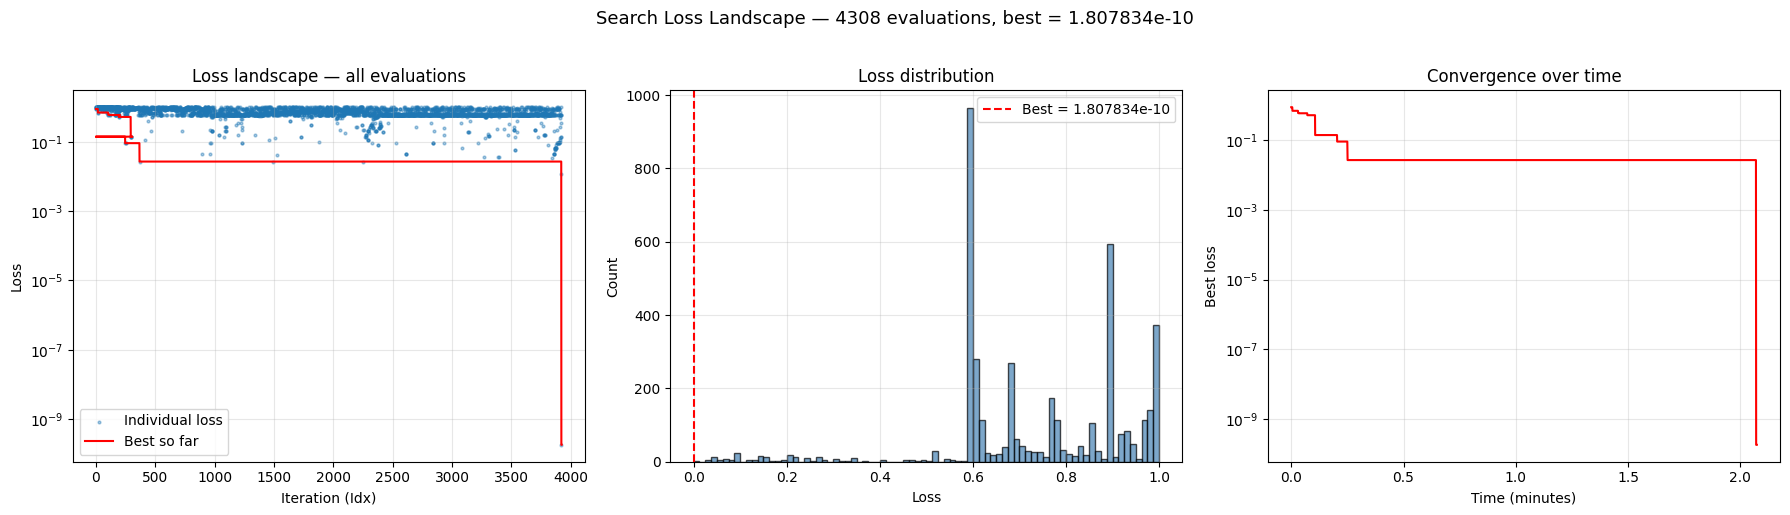

In [78]:
import matplotlib.pyplot as plt

# Load all evaluated configurations
df_loss = pd.read_csv(os.path.join(save_dir, "computation_file.csv"))

# Replace inf with NaN for cleaner plotting
df_loss["Loss"] = df_loss["Loss"].replace([np.inf, -np.inf], np.nan)

# Running minimum (best loss found so far at each step)
df_loss["BestSoFar"] = df_loss["Loss"].expanding().min()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1) All losses vs iteration index ─────────────────────────────────────
ax = axes[0]
ax.scatter(df_loss["Idx"], df_loss["Loss"], s=4, alpha=0.4, label="Individual loss")
ax.plot(df_loss["Idx"], df_loss["BestSoFar"], color="red", linewidth=1.5, label="Best so far")
ax.set_xlabel("Iteration (Idx)")
ax.set_ylabel("Loss")
ax.set_title("Loss landscape — all evaluations")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)

# ── 2) Distribution of losses (histogram) ────────────────────────────────
ax = axes[1]
finite_losses = df_loss["Loss"].dropna()
ax.hist(finite_losses, bins=80, edgecolor="black", alpha=0.7, color="steelblue")
ax.axvline(finite_losses.min(), color="red", linestyle="--", linewidth=1.5,
           label=f"Best = {finite_losses.min():.6e}")
ax.set_xlabel("Loss")
ax.set_ylabel("Count")
ax.set_title("Loss distribution")
ax.legend()
ax.grid(True, alpha=0.3)

# ── 3) Best loss over time ───────────────────────────────────────────────
ax = axes[2]
df_loss["TimeStamp"] = pd.to_datetime(df_loss["TimeStamp"])
elapsed = (df_loss["TimeStamp"] - df_loss["TimeStamp"].iloc[0]).dt.total_seconds() / 60
ax.plot(elapsed, df_loss["BestSoFar"], color="red", linewidth=1.5)
ax.set_xlabel("Time (minutes)")
ax.set_ylabel("Best loss")
ax.set_title("Convergence over time")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)

fig.suptitle(f"Search Loss Landscape — {len(df_loss)} evaluations, best = {finite_losses.min():.6e}",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# 7) Post - Processing

## Alignment

In [79]:
from dragon.utils.plot_functions import graph_to_all_formulas

# Load the best model
best_model_params = load_archi("save/NDVI_formula/best_model/x.pkl")
labels = [e.label for e in search_space]
best_model_dict = dict(zip(labels, best_model_params))
m_dag = best_model_dict['Dag'].matrix
n_dag = str_operations(best_model_dict["Dag"].operations)

# ─── Step 1: Run the model and find the best output channel ──────────────────
feature_names_list = X.columns.tolist()
num_feat = len(feature_names_list)

model = MetaArchi(best_model_dict, input_shape=(num_feat,)).to(device)
model.eval()

all_pred, all_true = [], []
with torch.no_grad():
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        pred = model(Xb)
        all_pred.append(pred.detach().cpu())
        all_true.append(yb.detach().cpu())

pred_all = torch.cat(all_pred)
true_all = torch.cat(all_true)

selected_c = 0
best_loss = np.inf
if len(pred_all.shape) > 1:
    for c in range(pred_all.shape[-1]):
        loss = 1 - (correl(pred_all[:, c:c+1], true_all))**2
        if loss < best_loss:
            best_loss = loss
            selected_c = c
    pred_all = pred_all[:, selected_c]

pred_all = pred_all.squeeze().numpy().astype(np.float64)
true_all = true_all.squeeze().numpy().astype(np.float64)
print(f"Selected output channel: {selected_c}  (loss = {best_loss:.8f})")

# ─── Step 2: Extract the formula for the SELECTED channel ────────────────────
try:
    all_formulas = graph_to_all_formulas(
        best_model_dict['Dag'].matrix,
        np.asarray(feature_names_list),
        best_model_dict['Dag'].operations
    )
    print(f"\nAll output-channel formulas ({len(all_formulas)} channels):")
    for i, f_expr in enumerate(all_formulas):
        marker = " <<< SELECTED" if i == selected_c else ""
        print(f"  [{i}]: {f_expr}{marker}")

    original_expr = all_formulas[selected_c]
    print(f"\nSelected formula: {original_expr}")
except Exception as e:
    original_expr = None
    all_formulas = []
    print(f"Error extracting formulas: {e}")

# ─── Step 3: Post-processing alignment (float64 to avoid overflow) ───────────
A = np.column_stack([pred_all, np.ones_like(pred_all)])
coeffs, _, _, _ = np.linalg.lstsq(A, true_all, rcond=None) # pas linalg plutot autre chose
a1, a0 = coeffs
pred_aligned = a1 * pred_all + a0
mse_final = np.mean((pred_aligned - true_all)**2)
print(f"\nPost-processing alignment: a1={a1:.6e}, a0={a0:.6e}, MSE={mse_final:.6e}")

# ─── Step 4: Final formula ───────────────────────────────────────────────────
if original_expr is not None:
    final_formula = f"{a1:.6e} * ({original_expr}) + {a0:.6e}"
    print(f"\nFINAL ALIGNED FORMULA: {final_formula}")

Selected output channel: 9  (loss = 0.00000000)

All output-channel formulas (13 channels):
  [0]: 1
  [1]: 1
  [2]: 1
  [3]: 1
  [4]: 1
  [5]: 1
  [6]: 1
  [7]: B6/(B1 + B6)
  [8]: B7/(B11 + B7)
  [9]: B8/(B4 + B8) <<< SELECTED
  [10]: B8A/(B6 + B8A)
  [11]: lat/(B8A + lat)
  [12]: 1/2

Selected formula: B8/(B4 + B8)

Post-processing alignment: a1=2.000000e+00, a0=-1.000000e+00, MSE=1.663138e-23

FINAL ALIGNED FORMULA: 2.000000e+00 * (B8/(B4 + B8)) + -1.000000e+00


In [613]:
best_model_params = load_archi("save/NDVI_formula/best_model/x.pkl")
labels = [e.label for e in search_space]
best_model_dict = dict(zip(labels, best_model_params))
m_dag = best_model_dict['Dag'].matrix
n_dag = str_operations(best_model_dict["Dag"].operations)

In [614]:
best_model_dict

{'Dag': ModuleList(
   (0): 
   (input shape) (np.int64(5),) -- (combiner) add -- (op) Identity() -- (activation) Identity() -- (output shape) (5,)
   (1): 
   (input shape) (np.int64(5),) -- (combiner) mul -- (op) SelectFeatures(feature_indices=[1, 2, 3]) -- (activation) Identity() -- (output shape) (3,)
   (2): 
   (input shape) (1,) -- (combiner) add -- (op) SelectFeatures(feature_indices=[0, 2, 4]) -- (activation) Identity() -- (output shape) (1,)
   (3): 
   (input shape) (np.int64(5),) -- (combiner) add -- (op) Sqrt() -- (activation) Identity() -- (output shape) (5,)
   (4): 
   (input shape) (1,) -- (combiner) add -- (op) Inverse() -- (activation) Identity() -- (output shape) (1,)
   (5): 
   (input shape) (1,) -- (combiner) mul -- (op) Negate() -- (activation) Identity() -- (output shape) (1,)
 )}

## Graph representation

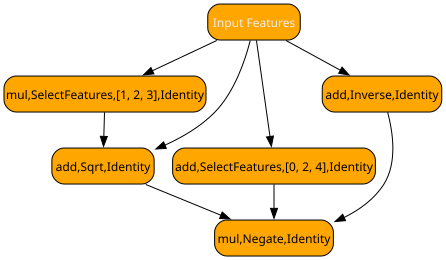

In [615]:
from IPython.display import display
import shutil
import importlib
import os

# Ensure notebook kernel can see Homebrew-installed binaries (macOS)
homebrew_dot = '/opt/homebrew/bin'
if homebrew_dot not in os.environ.get('PATH', ''):
    os.environ['PATH'] = os.environ.get('PATH', '') + ':' + homebrew_dot

# Optional graphviz: only use if the system 'dot' binary is available
_graphviz = None
try:
    if shutil.which("dot") is not None:
        _graphviz = importlib.import_module('graphviz')
except Exception:
    _graphviz = None


def _draw_with_networkx(adj_matrix, node_descriptions):
    """Fallback drawer using networkx + matplotlib (no system `dot` required)."""
    try:
        import networkx as nx
        import matplotlib.pyplot as plt
    except Exception as e:
        raise RuntimeError("networkx or matplotlib not available") from e

    G_nx = nx.DiGraph()
    for i, nd in enumerate(node_descriptions):
        G_nx.add_node(i, label=nd)
    for i in range(adj_matrix.shape[0]):
        for j in range(adj_matrix.shape[1]):
            if adj_matrix[i, j]:
                G_nx.add_edge(i, j)

    pos = nx.spring_layout(G_nx, seed=0)
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, max(4, len(node_descriptions) * 0.25)))
    nx.draw_networkx_nodes(G_nx, pos, node_color='#ffa600', node_size=1100)
    nx.draw_networkx_edges(G_nx, pos, arrows=True, arrowstyle='->', arrowsize=12)
    labels = {i: f"[{i}] {nd}" for i, nd in enumerate(node_descriptions)}
    nx.draw_networkx_labels(G_nx, pos, labels=labels, font_size=8)
    plt.axis('off')
    return plt.gcf()


def print_dag_text(adj_matrix, node_descriptions, show_matrix=False):
    """Print a compact, easy-to-read textual representation of the DAG.

    Shows for each node: index, children list, parents list, and the node description.
    """
    import textwrap
    n = adj_matrix.shape[0]

    parents = [[str(j) for j in range(n) if adj_matrix[j, i]] for i in range(n)]
    children = [[str(j) for j in range(n) if adj_matrix[i, j]] for i in range(n)]

    # build rows
    rows = []
    for i in range(n):
        desc = node_descriptions[i]
        # ensure compact string
        desc_s = textwrap.shorten(str(desc), width=60, placeholder='...')
        p = ','.join(parents[i]) if parents[i] else '-'
        c = ','.join(children[i]) if children[i] else '-'
        rows.append((i, c, p, desc_s))

    # column widths
    idx_w = max(3, max(len(str(r[0])) for r in rows) + 2)
    child_w = max(8, max(len(r[1]) for r in rows) + 2)
    parent_w = max(8, max(len(r[2]) for r in rows) + 2)
    desc_w = max(20, max(len(r[3]) for r in rows) + 2)

    # header
    header = f"{'Idx'.ljust(idx_w)}| {'Children'.ljust(child_w)}| {'Parents'.ljust(parent_w)}| Description"
    sep = '-' * (len(header) + 10)
    print(sep)
    print(header)
    print(sep)
    for i, c, p, desc in rows:
        print(f"[{str(i).rjust(idx_w-2)}] | {c.ljust(child_w)} | {p.ljust(parent_w)} | {desc}")
    print(sep)

    if show_matrix:
        print("Adjacency matrix:")
        print(adj_matrix)


def show_dag_graph(adj_matrix=None, node_descriptions=None, dag=None,
                   name_input="Input Features", color_input=None,
                   output_name="dag_viz", fmt="png", show_node_table=True,
                   prefer_text=False):
    """Display a DAG (reusable).

    Provide either:
      - dag (object with .matrix and .operations), or
      - both adj_matrix (np.ndarray) and node_descriptions (list from `str_operations`).

    Behavior:
      - Uses Graphviz if the `dot` binary is available and `prefer_text` is False.
      - Otherwise prints a clean textual DAG and uses NetworkX fallback for a simple visual if available.
    """
    if dag is not None:
        adj_matrix = dag.matrix
        node_descriptions = str_operations(dag.operations)

    if adj_matrix is None or node_descriptions is None:
        raise ValueError("Provide either `dag` or both `adj_matrix` and `node_descriptions`.")

    # If user explicitly prefers text, just print text and return
    if prefer_text:
        print_dag_text(adj_matrix, node_descriptions)
        return None

    dot_available = (_graphviz is not None)

    if dot_available:
        G = _graphviz.Digraph(output_name, format=fmt,
                              node_attr={'nodesep': '0.02', 'shape': 'box', 'rankstep': '0.02',
                                         'fontsize': '12', 'fontname': 'sans-serif'})
        # draw_cell expects: (graph, nodes, matrix, color, list_nodes, name_input=None, color_input=None)
        G, _ = draw_cell(G, node_descriptions, adj_matrix, "#ffa600", [], name_input=name_input, color_input=color_input)
        try:
            display(G)
        except Exception as e:
            print("Graphviz rendering failed — falling back to NetworkX drawing:", e)
            try:
                fig = _draw_with_networkx(adj_matrix, node_descriptions)
                display(fig)
            except Exception as e2:
                print("NetworkX fallback failed:", e2)
                dot_available = False

    if not dot_available:
        # Print textual representation first (clearest)
        print("\n--- Textual DAG view (clean) ---\n")
        print_dag_text(adj_matrix, node_descriptions)
        # Then try a simple visual fallback
        try:
            fig = _draw_with_networkx(adj_matrix, node_descriptions)
            display(fig)
        except Exception:
            # ignore: user requested text primarily
            pass

    return None


# Example usage (existing notebook variables):
# For a purely textual view: show_dag_graph(adj_matrix=m_dag, node_descriptions=n_dag, prefer_text=True)
# Default: will try graphviz then fall back to text+simple visual
show_dag_graph(adj_matrix=m_dag, node_descriptions=n_dag, name_input="Input Features")


## PySR

In [1]:
import subprocess, os

julia_bin = "/Users/elyaschikhaoui/Desktop/dragon/.dragonenv/julia_env/pyjuliapkg/install/bin/julia"
julia_project = "/Users/elyaschikhaoui/Desktop/dragon/.dragonenv/julia_env"

result = subprocess.run(
    [julia_bin, f"--project={julia_project}", "--threads=1", "run_pysr.jl"],
    capture_output=True, text=True, cwd=os.path.dirname(os.path.abspath("run_pysr.jl"))
)

print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)

Loading data from data/6000_points.csv...
Data: 2620 samples, 13 features
Features: ["B1", "B11", "B12", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "lat", "lon"]
Target: BSI

Starting symbolic regression...
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.920e-02  0.000e+00  y = -0.16352
3           2.590e-02  3.209e-01  y = -126.77 / B5
5           1.516e-02  2.677e-01  y = -0.35847 - (B11 * -0.00011511)
6           1.261e-02  1.841e-01  y = exp(B12 * -0.0014933) * -0.4941
7           5.559e-03  8.193e-01  y = (B12 / (B11 + B2)) + -0.44913
9           3.553e-03  2.238e-01  y = ((B12 + -131.06) / (B6 / 0.43405)) + -0.34088
11          1.228e-03  5.312e-01  y = ((B5 + B11) / (B1 + (B8 / 0.47874))) + -0.64421
12          2.450e-05  3.915e+00  y = (-1.4092 / exp((B11 + B4) / (B8 + B2))) + 0.51841
13          4.025e-27  5.016e+01  y = (-2 / (((B11 + B4) / (B8 + B2)) + 1)) + 1
─

In [ ]:
model.fit(X, z)

# 8) Comments and further improvement

Random forest faire de l'importance features, tester sans l'importance selection pour NDVI, récupérer les formules du papier pysr pour faire les tests

on évalue deux graphes pour voir si c'est les mêmes sur la poplation initiale, on continue de tirer des randoms tant qu'ya pas de solutioins K_init*0.7 différents (dans Mutant_ECB on stocke)
mpi4py pour paralléliser

AdamW pour l'optim, sur Dragon tutorials teaching tp boucle d'entrainement pytorch

Et si on faisait une step d'optimisation des constantes mais seulement après ? On optimise les 1 par exemple pour obtenir des constantes.

XGBOOST qui donne un score pour ensuite le feed à selectfeatures, librairie XGboost ou sklearn
random forrest regression (devient non linéaire)
selection n features
si on arrive à chaque fois à l'avoir avec K, T, E différents
srun -u 
regarder le nombre d'itérations que pysr prend (100 par défaut)

Prendre une uniforme d'exponentielle avec r entre 10**u u uniforme entre 0 et 10 et m de la forme 10 **v et v entre 0 et 15
tester si pysr trouve rapidement
Try with the benchmark
Decomposition en elements simple, pius ensuite on weight numeratuer et denominateur A/B devient (aA+b)/(cB+d)
Add the pytorch loop

See if I do this up there it has impact

Tableau de comparaison en document pour savoir le runtime la convergence, la loss pour pouvoir se comparer

turn on and off the new features that I implement

- Distance terre soleil à trouver
- Ajouter un truc de sanity check pour avoir les logs mais pas les logs négatifs
- Phase d'optimisation des constantes vers la fin de l'exploration (la proba de l'optimisation des constantes devraient augmenter)
- Regarder la MSE, faire une moyenne harmonique entre la MSE et la correlation, un score. Une fois que j'ai avancé suffisamment, rendre le biais le plus petit possible
- Passer la cible en log(z)
- Passer le paramètre de pas dans la boucle d'optimisation

- Mélanger mse et corr, mse fin d'exploration
- optimiser la valeur de puissance
- monter la formule à la puissance plutot 
- log verif valeur négative

- xgboost pour l'optim puissance, ou torch solve
- Suffit d'ajouter l'optim des puissances

- v = H0 * D (Done)
- Plot un nuage de points
- Simplification et constantes négligeables devant les variables
- Just adding MSE should help a lot

Instead of searching for f(X) directly, search for A(X) and B(X) such that z ≈ A/B. This is a general decomposition that works for any rational formula

selon la forme de y et l'input choisir 
faire l'optim avec Aidar, optimisation réseaux de neurones
Si on normalise ou non les données ça change qqch ? juste normalise l'entrée
denoising.py --> regresseur
poru jeudi
l'optim, le denoising et regarder les distribution de données
comparer avce des données générées contre les données sattelites

PySR et données normailsées 
regarder sur 1000 itérations 

Pour jeudi :
1) PySR (done) et données normalisées (search lancées)
2) Optim des constantes avec torch
3) parallélisation
4) Denoising

N on l'utilise pas, c'est le nombre de fois qu'on fait tourner l'algo d'otpim

print of formula each time we have a best loss found in a text file

simplification earlier in the process

Add weights to CatVar, several MutantUCB to not put SelectFeatures in the next, different one dimensioin entries tensors, higher probability to choose one feature

random forrest !

def __eq__(self, x)
gA==gB ?
Pour Mutant_ECB voir si ya modif possible

Causal similarity entre les deux, faie un == sur les matrices d'adj ou un truc de ressamblance
Dans l'opérateur de mutation

------------------
Alternative à Mutant_ECB: la formule c'est un seul vecteur pour simplifier
On peut passer sur l'algo génétique 
------------------
On peut faire un algo gen 
select_next_configuration pour modifier la mutation, si l'algo trouve 10 fois un identique je chosis un autre individu à muter
cosine similarity entre deux graphes
------------------
Tester une loss par population pour faire de la spécialisation selon l'environnement, aL1 + bL2 +cL3 où a+b+c = 1, on peut les sampler de façon aléatoire. Le but de cette méthode c'est de réconcilier la spécialisation entre les populations

L1 = corr, L2= 1-MSE/(max_batch(MSE)+eps), L3 <-- MAE
------------------
Initialisation de la première population: imposer toutes les catégories d'opérations, initialisation avec toutes les opérations et apparitiion de toutes les features en fonction du XGBoost
------------------

Savoir quand je retombe sur les mêmes formules: vue statistique en fonction du temps, avoir un vrai logging statistique de ce qu'il se passe
------------------
Faire une classe fille de mutant pour voir quand je bouge vers une autre graphe ou non
------------------
Améliorer encore la loss, pour en faire vraiment une qui correspond à une recherche de formules, plus adaptée aux passages au ratio par exemple

Solution : identifier les sous-patterns comme le ferait un scientifique. Exemple de cette fonction: $NIRv = B_8 \times \frac{B_8-B_4}{B_8+B_4} $ qui n'a pas besoin de plus de 5-6 noeuds pour être trouvée.

Solutions: 

1. Cheating solution :
- ratio_form  →  (a - b) / (a + b)     # NDVI-type
- scaled_form →  ratio_form × leaf      # NIRv-type
- linear_comb →  α·x + β·y             # inputs to BSI ratio

2. Dimensional unit strategy:
imposing units makes the search space constrained

3. Library learner:
 After each successful search, the discovered formula becomes a new primitive for future runs. This is the "library learning" idea from AI Feynman / DreamCoder.